# Tópicos em Otimização Irrestrita

### Pacotes importados

In [1]:
using LinearAlgebra
using Printf
using Plots

In [2]:
function imprimir_tabela_1d(hist)
    @printf("%5s %24s %24s
", "k", "x", "F(x)")
    for (k, x, fx) in hist
        @printf("%5d %24.16e %24.16e
", k, x, fx)
    end
end

imprimir_tabela_1d (generic function with 1 method)

### Machine epsilon

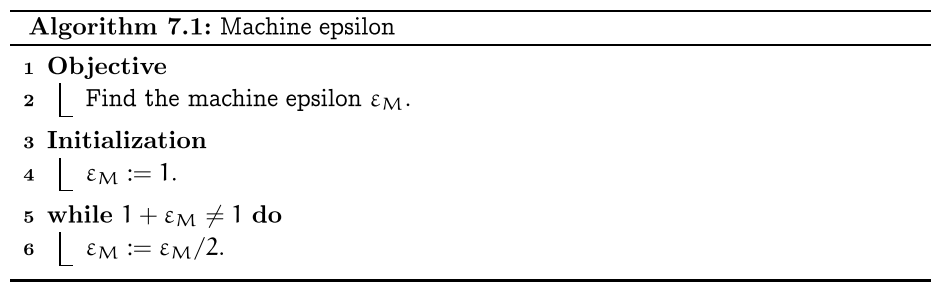

In [3]:
ϵ = 1.0
while 1.0 + ϵ/2.0 > 1.0
    ϵ /= 2.0
end

println("Machine epsilon calculado = ", ϵ)
println("eps(Float64) do Julia     = ", eps(Float64))

Machine epsilon calculado = 2.220446049250313e-16
eps(Float64) do Julia     = 2.220446049250313e-16


### Newton's method: one variable

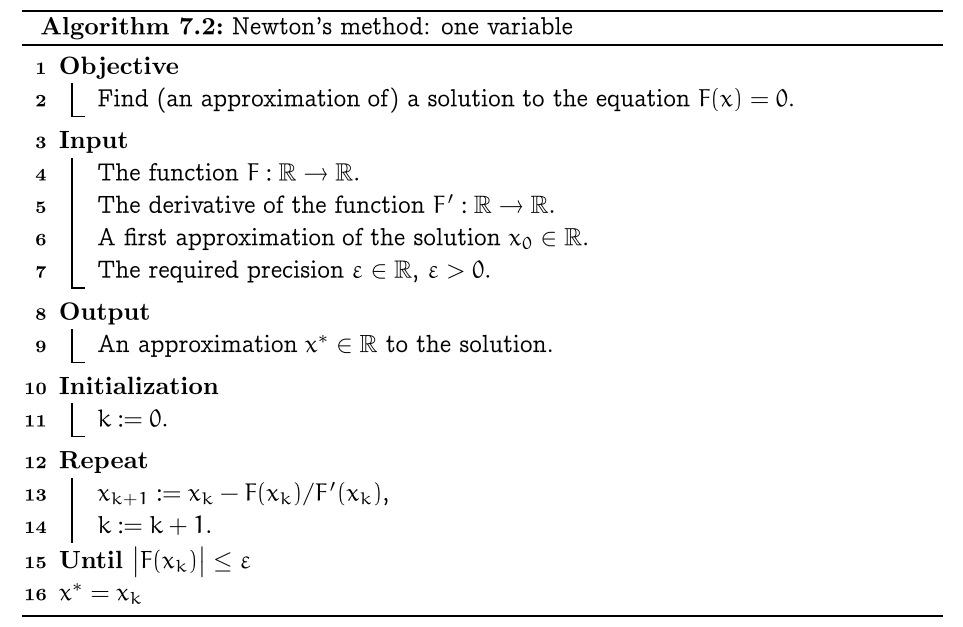

Take the equation: $F(x) = x^2 - 2 = 0$. Apply the Newton's method with $x_0 = 2, \epsilon = 10^{-15}$. Present the results such as the following:

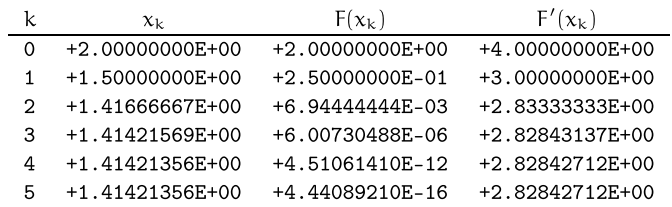

Also plot the graph with the iterations $\times$ the value of F(x).

Convergiu? true
Raiz aproximada = 1.4142135623730951
F(raiz) = 4.440892098500626e-16
    k                        x                     F(x)
    0   2.0000000000000000e+00   2.0000000000000000e+00
    1   1.5000000000000000e+00   2.5000000000000000e-01
    2   1.4166666666666667e+00   6.9444444444446418e-03
    3   1.4142156862745099e+00   6.0073048828712672e-06
    4   1.4142135623746899e+00   4.5106141044470860e-12
    5   1.4142135623730951e+00   4.4408920985006262e-16


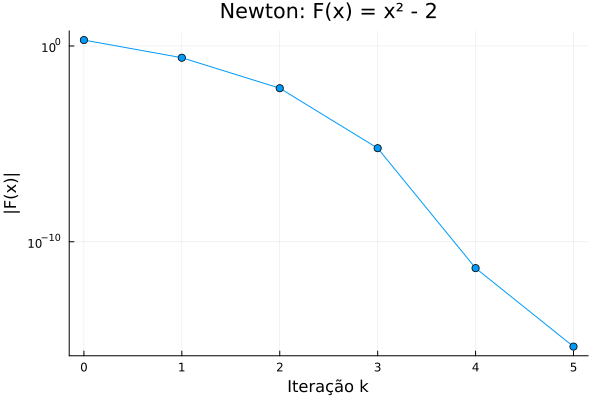

In [4]:
function newton_1d(F, dF, x0; tol=1e-15, maxiter=100)
    x = Float64(x0)
    hist = Tuple{Int,Float64,Float64}[]

    for k in 0:maxiter
        fx = F(x)
        push!(hist, (k, x, fx))

        if abs(fx) < tol
            return x, hist, true
        end

        dfx = dF(x)
        if abs(dfx) < eps(Float64)
            println("Derivada muito próxima de zero. Método interrompido.")
            return x, hist, false
        end

        x = x - fx/dfx
    end

    return x, hist, false
end

F(x) = x^2 - 2
dF(x) = 2x

raiz, hist, convergiu = newton_1d(F, dF, 2.0; tol=1e-15)

println("Convergiu? ", convergiu)
println("Raiz aproximada = ", raiz)
println("F(raiz) = ", F(raiz))
imprimir_tabela_1d(hist)

ks = [h[1] for h in hist]
valores = [abs(h[3]) for h in hist]
plot(ks, valores,
     marker=:circle,
     yscale=:log10,
     xlabel="Iteração k",
     ylabel="|F(x)|",
     title="Newton: F(x) = x² - 2",
     legend=false)# codigo aqui

Another example: $F(x)=x-\sin(x)$. Run the example with $x_0=1$ and $\varepsilon=10^{-15}$.

Convergiu? true
Raiz aproximada = 1.7074312016207497e-5
F(raiz) = 8.296179498587519e-16
    k                        x                     F(x)
    0   1.0000000000000000e+00   1.5852901519210350e-01
    1   6.5514507204243044e-01   4.5870786040895783e-02
    2   4.3359036836349274e-01   1.3458737959401001e-02
    3   2.8814840089250121e-01   3.9709484604172895e-03
    4   1.9183231215063862e-01   1.1743969232932971e-03
    5   1.2780966756070827e-01   3.4768434920498525e-04
    6   8.5183233602864061e-02   1.0298015675494487e-04
    7   5.6781952786616366e-02   3.0507717045380467e-05
    8   3.7852600781113258e-02   9.0386758038185633e-06
    9   2.5234464535015051e-02   2.6780408849888526e-06
   10   1.6822797810871225e-02   7.9348236674617323e-07
   11   1.1215145640462639e-02   2.3510440783081066e-07
   12   7.4767480865235488e-03   6.9660370574306518e-08
   13   4.9844940803018710e-03   2.0640084159168071e-08
   14   3.3229946775363518e-03   6.1155771150303573e-09
   15   2.215329

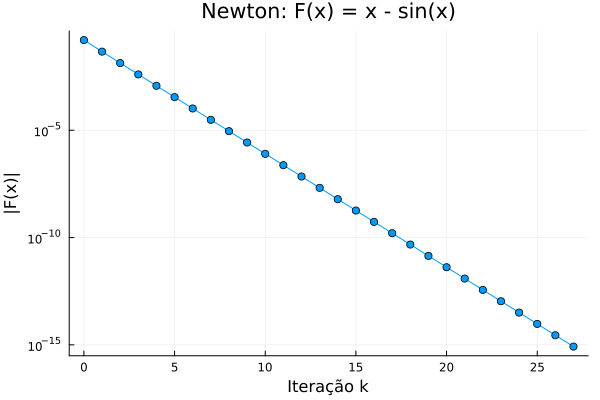

In [5]:
F2(x) = x - sin(x)
dF2(x) = 1 - cos(x)

raiz2, hist2, convergiu2 = newton_1d(F2, dF2, 1.0; tol=1e-15, maxiter=100)

println("Convergiu? ", convergiu2)
println("Raiz aproximada = ", raiz2)
println("F(raiz) = ", F2(raiz2))
imprimir_tabela_1d(hist2)

ks2 = [h[1] for h in hist2]
valores2 = [abs(h[3]) for h in hist2]
plot(ks2, valores2,
     marker=:circle,
     yscale=:log10,
     xlabel="Iteração k",
     ylabel="|F(x)|",
     title="Newton: F(x) = x - sin(x)",
     legend=false)# codigo aqui

Another example: $F(x)=\arctan(x)$. Run the example with $x_0=1.5$ and $\varepsilon=10^{-15}$. We set `maxiter` to 10, as the algorithm is not converging.

Derivada muito próxima de zero. Método interrompido.
Convergiu? false
Último valor de x = -2.3830288973552125e13
F(x) = -1.5707963267948546
    k                        x                     F(x)
    0   1.5000000000000000e+00   9.8279372324732905e-01
    1  -1.6940796005538195e+00  -1.0375463591378908e+00
    2   2.3211269614383880e+00   1.1640020424219752e+00
    3  -5.1140878367775136e+00  -1.3776945287027522e+00
    4   3.2295683914210016e+01   1.5398423269080117e+00
    5  -1.5753169508212043e+03  -1.5701615339900847e+00
    6   3.8949760077608842e+06   1.5707960700539056e+00
    7  -2.3830288973552125e+13  -1.5707963267948546e+00


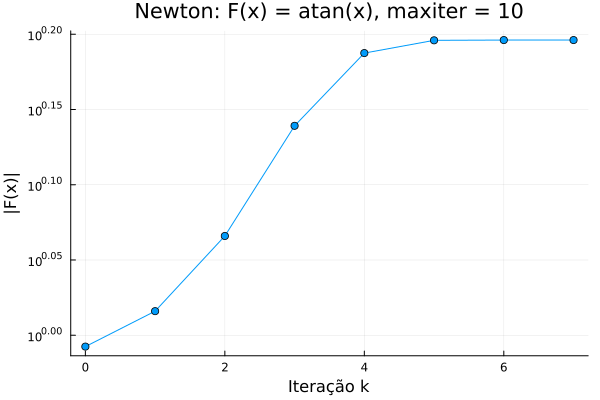

In [6]:
F3(x) = atan(x)
dF3(x) = 1/(1 + x^2)

raiz3, hist3, convergiu3 = newton_1d(F3, dF3, 1.5; tol=1e-15, maxiter=10)

println("Convergiu? ", convergiu3)
println("Último valor de x = ", raiz3)
println("F(x) = ", F3(raiz3))
imprimir_tabela_1d(hist3)

ks3 = [h[1] for h in hist3]
valores3 = [abs(h[3]) for h in hist3]
plot(ks3, valores3,
     marker=:circle,
     yscale=:log10,
     xlabel="Iteração k",
     ylabel="|F(x)|",
     title="Newton: F(x) = atan(x), maxiter = 10",
     legend=false)

### Algorithm 7.3: Newton's method: $n$ variables

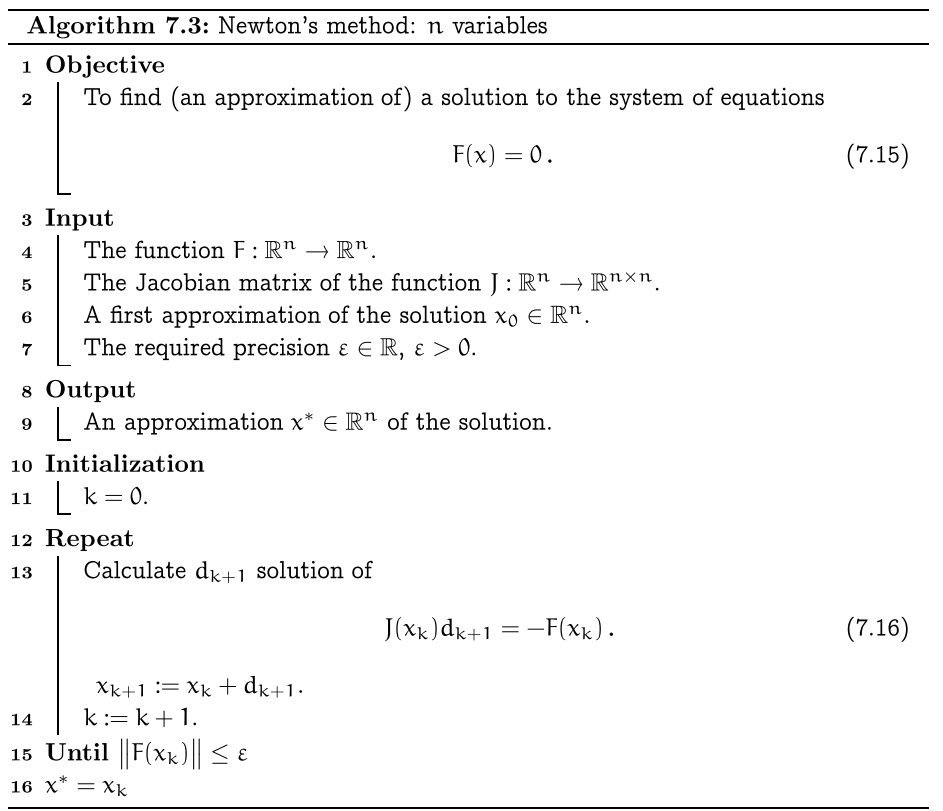

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Convergiu? true
Solução aproximada = [-1.0463793574265223e-16, 1.0000000000000002]
F(solução) = [0.0, 4.440892098500626e-16]
    k                           x1                           x2           ||F(x)||
    0       1.0000000000000000e+00       1.0000000000000000e+00     3.45723769e+00
    1       1.5235921363875715e-01       1.1952815727224857e+00     1.15470871e+00
    2      -1.0837680936145927e-02       1.0361111672588803e+00     1.14042558e-01
    3      -8.8966460146966929e-04       1.0015353164941012e+00     3.94232976e-03
    4      -1.3700887510573884e-06       1.0000029387079050e+00     8.07998556e-06
    5      -5.5384521961342160e-12       1.0000000000107949e+00     2.88311226e-11
    6      -1.0463793574265223e-16       1.0000000000000002e+00     4.44089210e-16


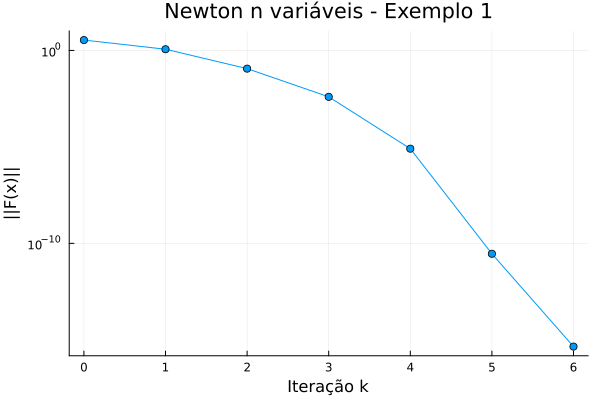

In [7]:
function newton_nd(F, J, x0; tol=1e-15, maxiter=100)
    x = Float64.(x0)
    hist = []

    for k in 0:maxiter
        Fx = F(x)
        push!(hist, (k, copy(x), norm(Fx)))

        if norm(Fx) < tol
            return x, hist, true
        end

    
        Δx = J(x) \ (-Fx)
        x = x + Δx
    end

    return x, hist, false
end

function imprimir_tabela_nd(hist)
    @printf("%5s %28s %28s %18s
", "k", "x1", "x2", "||F(x)||")
    for (k, x, nFx) in hist
        @printf("%5d %28.16e %28.16e %18.8e
", k, x[1], x[2], nFx)
    end
end

F_nd1(x) = [(x[1] + 1)^2 + x[2]^2 - 2;
            exp(x[1]) + x[2]^3 - 2]

J_nd1(x) = [2*(x[1] + 1)   2*x[2];
            exp(x[1])      3*x[2]^2]

x0 = [1.0, 1.0]
sol1, hist_nd1, conv_nd1 = newton_nd(F_nd1, J_nd1, x0; tol=1e-15)

println("Convergiu? ", conv_nd1)
println("Solução aproximada = ", sol1)
println("F(solução) = ", F_nd1(sol1))
imprimir_tabela_nd(hist_nd1)

plot([h[1] for h in hist_nd1], [h[3] for h in hist_nd1],
     marker=:circle,
     yscale=:log10,
     xlabel="Iteração k",
     ylabel="||F(x)||",
     title="Newton n variáveis - Exemplo 1",
     legend=false)


Example: $F(x)=\left(\begin{array}{c}x_1^3 - 3 x_1 x_2^2 -1 \\ x_2^3 - 3x_1^2 x_2\end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Convergiu? true
Solução aproximada = [1.0, 4.930380657631324e-31]
F(solução) = [0.0, -1.4791141972893971e-30]
    k                           x1                           x2           ||F(x)||
    0       1.0000000000000000e+00       1.0000000000000000e+00     3.60555128e+00
    1       6.6666666666666674e-01       5.0000000000000000e-01     1.31996416e+00
    2       5.7884444444444449e-01      -1.2746666666666673e-01     8.43736321e-01
    3       1.2469639815750162e+00       3.1357842515499729e-01     1.54161108e+00
    4       1.0089481977515047e+00       1.1367796515490114e-01     3.45904691e-01
    5       9.8786804597837563e-01       3.8368436428647262e-03     3.77115051e-02
    6       1.0001341442102127e+00      -9.5322185096268289e-05     4.93755294e-04
    7       1.0000000089100061e+00      -2.5568132902689189e-08     8.12284357e-08
    8       9.9999999999999944e-01      -4.5562445194162895e-16     2.15445629e-15
    9       1.0000000000000000e+00       4.9303806576313238e

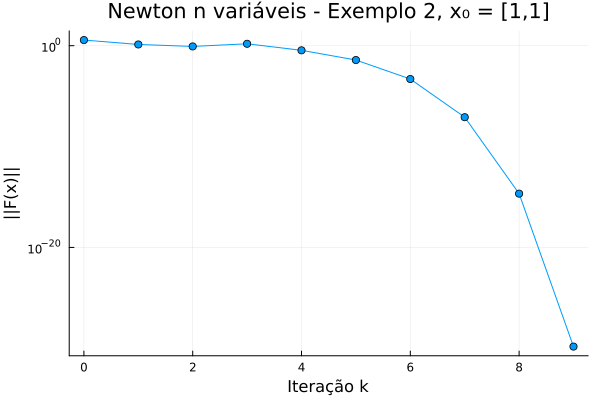

In [8]:
F_nd2(x) = [x[1]^3 - 3*x[1]*x[2]^2 - 1;
            x[2]^3 - 3*x[1]^2*x[2]]

J_nd2(x) = [3*x[1]^2 - 3*x[2]^2    -6*x[1]*x[2];
            -6*x[1]*x[2]             3*x[2]^2 - 3*x[1]^2]

x0_a = [1.0, 1.0]
sol2a, hist_nd2a, conv_nd2a = newton_nd(F_nd2, J_nd2, x0_a; tol=1e-15, maxiter=100)

println("Convergiu? ", conv_nd2a)
println("Solução aproximada = ", sol2a)
println("F(solução) = ", F_nd2(sol2a))
imprimir_tabela_nd(hist_nd2a)

plot([h[1] for h in hist_nd2a], [h[3] for h in hist_nd2a],
     marker=:circle,
     yscale=:log10,
     xlabel="Iteração k",
     ylabel="||F(x)||",
     title="Newton n variáveis - Exemplo 2, x₀ = [1,1]",
     legend=false)


Run the example with $x_0= \left(\begin{array}{c} -1 \\ -1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Convergiu? true
Solução aproximada = [-0.49999999999999994, -0.8660254037844386]
F(solução) = [-2.220446049250313e-16, -1.1102230246251565e-16]
    k                           x1                           x2           ||F(x)||
    0      -1.0000000000000000e+00      -1.0000000000000000e+00     2.23606798e+00
    1      -6.6666666666666674e-01      -8.3333333333333337e-01     5.40398960e-01
    2      -5.0869191618745457e-01      -8.4109987441337830e-01     7.78404264e-02
    3      -4.9932999564375130e-01      -8.6626917178800567e-01     2.13865036e-03
    4      -4.9999991136991290e-01      -8.6602490315688918e-01     1.52523667e-06
    5      -4.9999999999995542e-01      -8.6602540378469317e-01     7.75299009e-13
    6      -4.9999999999999994e-01      -8.6602540378443860e-01     2.48253415e-16


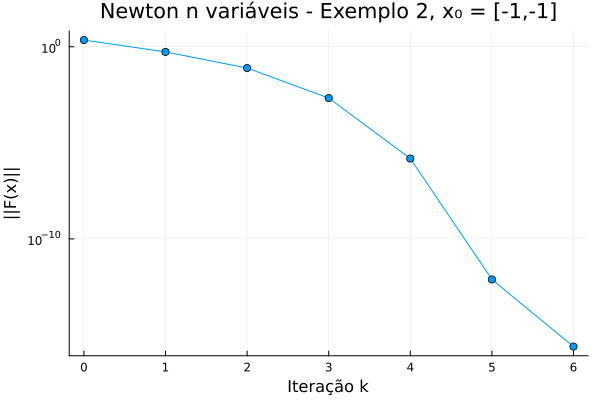

In [9]:
x0_b = [-1.0, -1.0]
sol2b, hist_nd2b, conv_nd2b = newton_nd(F_nd2, J_nd2, x0_b; tol=1e-15, maxiter=100)

println("Convergiu? ", conv_nd2b)
println("Solução aproximada = ", sol2b)
println("F(solução) = ", F_nd2(sol2b))
imprimir_tabela_nd(hist_nd2b)

plot([h[1] for h in hist_nd2b], [h[3] for h in hist_nd2b],
     marker=:circle,
     yscale=:log10,
     xlabel="Iteração k",
     ylabel="||F(x)||",
     title="Newton n variáveis - Exemplo 2, x₀ = [-1,-1]",
     legend=false)

Run the example with $x_0= \left(\begin{array}{c} 0 \\ 1 \end{array}\right)$ and $\varepsilon = 10^{-15}$

Convergiu? true
Solução aproximada = [-0.5000000000000001, 0.8660254037844387]
F(solução) = [4.440892098500626e-16, -2.220446049250313e-16]
    k                           x1                           x2           ||F(x)||
    0       0.0000000000000000e+00       1.0000000000000000e+00     1.41421356e+00
    1      -3.3333333333333331e-01       6.6666666666666674e-01     5.97204278e-01
    2      -5.8222222222222220e-01       9.2444444444444440e-01     3.31281254e-01
    3      -5.0879080328931914e-01       8.6816551188734914e-01     2.73128276e-02
    4      -5.0006873906739269e-01       8.6598221869254011e-01     2.43535921e-04
    5      -4.9999999628902975e-01       8.6602539833858683e-01     1.97701144e-08
    6      -5.0000000000000011e-01       8.6602540378443871e-01     4.96506831e-16


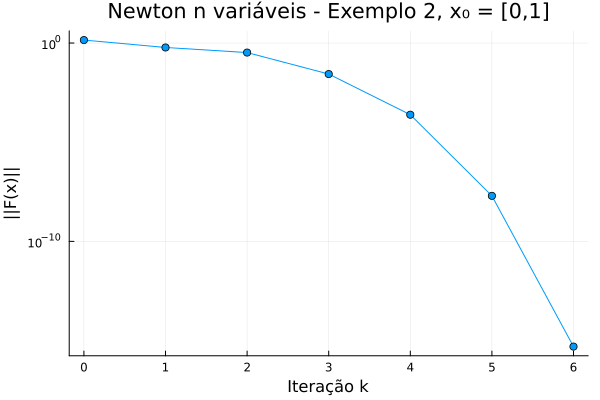

In [10]:
x0_c = [0.0, 1.0]
sol2c, hist_nd2c, conv_nd2c = newton_nd(F_nd2, J_nd2, x0_c; tol=1e-15, maxiter=100)

println("Convergiu? ", conv_nd2c)
println("Solução aproximada = ", sol2c)
println("F(solução) = ", F_nd2(sol2c))
imprimir_tabela_nd(hist_nd2c)

plot([h[1] for h in hist_nd2c], [h[3] for h in hist_nd2c],
     marker=:circle,
     yscale=:log10,
     xlabel="Iteração k",
     ylabel="||F(x)||",
     title="Newton n variáveis - Exemplo 2, x₀ = [0,1]",
     legend=false)